# 5-Qubit Xmon Processor (Barends *et al.*, 2014)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/qiskit-community/qiskit-metal/blob/main/tutorials%2FAppendix%20C%20Circuit%20examples%2FF.%20Small-quantum-chips%2F52-Barends_5Qubit_Xmon_Processor.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/qiskit-community/qiskit-metal/main?labpath=tutorials%2FAppendix%20C%20Circuit%20examples%2FF.%20Small-quantum-chips%2F52-Barends_5Qubit_Xmon_Processor.ipynb)

> 💡 **Running in Colab or Binder?** Uncomment the install cell below.

Reproduces the architecture of the 5-qubit linear Xmon processor from Barends *et al.*, ["Superconducting quantum circuits at the surface code threshold for fault tolerance"](https://doi.org/10.1038/nature13171), Nature **508**, 500–503 (2014) — the device that demonstrated single- and two-qubit gate fidelities above the surface-code fault-tolerance threshold, built by the team that shortly after formed Google Quantum AI. See also Barends *et al.*, ["Coherent Josephson Qubit Suitable for Scalable Quantum Integrated Circuits"](https://doi.org/10.1103/PhysRevLett.111.080502), PRL **111**, 080502 (2013), for the Xmon qubit design.

Five Xmon transmons in a 1-D chain, each with an individual meandered readout resonator, frequency-multiplexed onto a single feedline through a directional coupler per qubit; XY and Z control lines are routed to wirebond pads on all four chip edges.

Design adapted from the [Quantum Device Workshop 2026 capstone-project solution](https://github.com/quantum-device-consortium/qdw26-workshop-materials/blob/main/workshops/design-project/notebooks/solutions/05_project_layout.ipynb), implemented by Murat Can Sarihan (Google Quantum AI). Component parameters and routing here are a physical-layout example inspired by the published device, not the fabricated chip's actual mask.

In [1]:
# In Colab / Binder, uncomment to install Quantum Metal (lite, no Qt).
# Locally you should already have it via `pip install quantum-metal` or
# `pip install 'quantum-metal[gui]'` for the desktop GUI.
# !pip install -q quantum-metal

> 💡 **Using this tutorial without the Qt GUI**
>
> This notebook only uses the headless API (`qm.view`) so it runs unmodified on Colab, Binder, JupyterHub, or any environment without Qt. See [1.1 Quick start](https://qiskit-community.github.io/qiskit-metal/tut/1-Overview/1.1-Quick-start.html) for a complete runnable walkthrough and [`docs/headless-usage.rst`](https://qiskit-community.github.io/qiskit-metal/headless-usage.html) for the full headless/GUI split.

### 1. Setup

In [2]:
import os
os.environ.setdefault('QISKIT_METAL_HEADLESS', 'True')

from qiskit_metal import designs, Dict
import qiskit_metal as qm
from qiskit_metal.qlibrary.qubits.transmon_cross_fl import TransmonCrossFL
from qiskit_metal.qlibrary.couplers.coupled_line_tee import CoupledLineTee
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround
from qiskit_metal.qlibrary.tlines.straight_path import RouteStraight
from qiskit_metal.qlibrary.tlines.framed_path import RouteFramed
from qiskit_metal.qlibrary.tlines.anchored_path import RouteAnchors
from qiskit_metal.qlibrary.lumped.cap_n_interdigital import CapNInterdigital

design = designs.DesignPlanar()
design.chips.main.size.size_x = '6.0mm'
design.chips.main.size.size_y = '6.0mm'
design.overwrite_enabled = True

print('Design initialized with a 6x6 mm substrate.')

Design initialized with a 6x6 mm substrate.


### 2. Place the five Xmon qubits (Q0–Q4)

Each `TransmonCrossFL` gets a flux line (south arm) and a readout connection pad (north arm); a hand-placed `OpenToGround` next to each qubit becomes the XY drive-line coupling point.

In [3]:
qubit_pitch = 0.45  # mm
qubits, xy_pads = [], []
for i in range(5):
    x_pos = (i - 2) * qubit_pitch
    q = TransmonCrossFL(design, f'Q{i}', options=dict(
        pos_x=f'{x_pos}mm', pos_y='0.0mm', orientation='0',
        cross_width='30um', cross_length='190um', cross_gap='50um',
        make_fl=True,
        fl_options=dict(t_gap='3um', t_inductive_gap='3um', t_offset='0um',
                        t_top='15um', t_width='5um'),
        connection_pads=dict(readout=dict(
            connector_type='0', claw_length='40um', ground_spacing='5um',
            claw_width='10um', claw_gap='6um', connector_location='90')),
    ))
    qubits.append(q)
    xy_pads.append(OpenToGround(design, f'XY_pad_{i}', options=dict(
        pos_x=f'{x_pos - 0.1}mm', pos_y='-0.18mm', orientation='90',
        width='10um', gap='6um', termination_gap='6um')))

print('Placed qubits Q0-Q4 and their XY coupling pads.')

Placed qubits Q0-Q4 and their XY coupling pads.


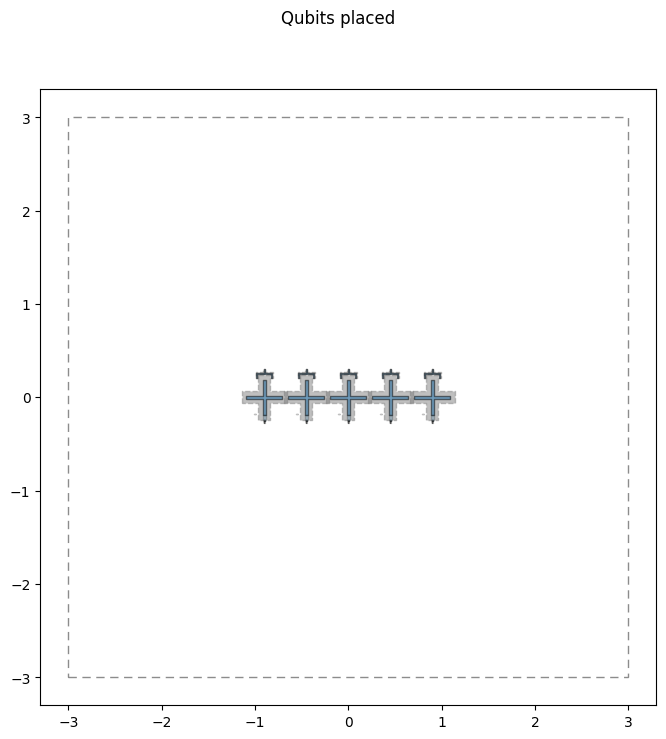

In [4]:
fig = qm.view(design)
fig.suptitle('Qubits placed')
fig

### 3. Multiplexed readout feedline

A single feedline runs across the top of the chip. A `CoupledLineTee` directional coupler sits above each qubit, and `CapNInterdigital` components terminate the feedline's input/output before it reaches the edge launchpads.

In [5]:
total_purcell_length_mm = 0  # tracked from the coupler taps onward

couplers = []
for i in range(5):
    x_pos = (i - 2) * qubit_pitch
    couplers.append(CoupledLineTee(design, f'CLT{i}', options=dict(
        pos_x=f'{x_pos}mm', pos_y='1.5mm', orientation='0',
        coupling_length='200um', coupling_space='4um')))
    total_purcell_length_mm += 0.2

# Wirebond launchpads, three per edge, 1.5 mm apart
LaunchpadWirebond(design, 'LP_W1', options=dict(pos_x='-2.8mm', pos_y='-1.5mm', orientation='0'))
LaunchpadWirebond(design, 'LP_W2', options=dict(pos_x='-2.8mm', pos_y='0.0mm', orientation='0'))
LaunchpadWirebond(design, 'LP_W3', options=dict(pos_x='-2.8mm', pos_y='1.5mm', orientation='0'))
LaunchpadWirebond(design, 'LP_E1', options=dict(pos_x='2.8mm', pos_y='-1.5mm', orientation='180'))
LaunchpadWirebond(design, 'LP_E2', options=dict(pos_x='2.8mm', pos_y='0.0mm', orientation='180'))
LaunchpadWirebond(design, 'LP_E3', options=dict(pos_x='2.8mm', pos_y='1.5mm', orientation='180'))
LaunchpadWirebond(design, 'LP_S1', options=dict(pos_x='-1.5mm', pos_y='-2.8mm', orientation='90'))
LaunchpadWirebond(design, 'LP_S2', options=dict(pos_x='0.0mm', pos_y='-2.8mm', orientation='90'))
LaunchpadWirebond(design, 'LP_S3', options=dict(pos_x='1.5mm', pos_y='-2.8mm', orientation='90'))
LaunchpadWirebond(design, 'LP_N1', options=dict(pos_x='-1.5mm', pos_y='2.8mm', orientation='270'))
LaunchpadWirebond(design, 'LP_N2', options=dict(pos_x='0.0mm', pos_y='2.8mm', orientation='270'))
LaunchpadWirebond(design, 'LP_N3', options=dict(pos_x='1.5mm', pos_y='2.8mm', orientation='270'))

cap_in = CapNInterdigital(design, 'Cap_input', options=dict(pos_x='-2.4mm', pos_y='1.5mm', orientation='270'))
cap_out = CapNInterdigital(design, 'Cap_output', options=dict(pos_x='-1mm', pos_y='2.1mm', orientation='90'))

print('Placed launchpads and feedline terminations.')

Placed launchpads and feedline terminations.


In [6]:
RouteStraight(design, 'Feed_in_lp', options=dict(pin_inputs=dict(
    start_pin=dict(component='LP_W3', pin='tie'),
    end_pin=dict(component='Cap_input', pin='south_end'))))

purcell_left = RouteStraight(design, 'Feed_in_clt', options=dict(pin_inputs=dict(
    start_pin=dict(component='Cap_input', pin='north_end'),
    end_pin=dict(component='CLT0', pin='prime_start'))))
total_purcell_length_mm += purcell_left.length

for i in range(4):
    feed_i = RouteStraight(design, f'Feed_mid_{i}', options=dict(pin_inputs=dict(
        start_pin=dict(component=f'CLT{i}', pin='prime_end'),
        end_pin=dict(component=f'CLT{i+1}', pin='prime_start'))))
    total_purcell_length_mm += feed_i.length

purcell_right = RouteAnchors(design, 'Feed_out_clt', options=dict(
    pin_inputs=dict(start_pin=dict(component='CLT4', pin='prime_end'),
                     end_pin=dict(component='Cap_output', pin='north_end')),
    anchors=Dict({0: (1.7, 1.5), 1: (1.7, 1.8), 2: (-2.4, 1.8)}),
    fillet='100um', advanced=Dict(avoid_collision=False)))
total_purcell_length_mm += purcell_right.length

RouteAnchors(design, 'Feed_out_lp', options=dict(
    pin_inputs=dict(start_pin=dict(component='Cap_output', pin='south_end'),
                     end_pin=dict(component='LP_N1', pin='tie')),
    lead=Dict(start_straight='200um', end_straight='100um'),
    fillet='20um', advanced=Dict(avoid_collision=False)))

print('Feedline routed.')
print(f'Total Purcell-filter feedline length: {total_purcell_length_mm:.3f} mm')

Feedline routed.
Total Purcell-filter feedline length: 9.028 mm


### 4. Staggered meander readout resonators

Each qubit's resonator gets a different total length (4.41–4.57 mm in 0.04 mm steps) so all five readout tones land at distinct frequencies for frequency-domain multiplexing on the single feedline.

In [7]:
resonator_lengths = ['4.41mm', '4.45mm', '4.49mm', '4.53mm', '4.57mm']

for i in range(5):
    RouteMeander(design, f'ReadoutRes{i}', options=dict(
        pin_inputs=dict(start_pin=dict(component=f'Q{i}', pin='readout'),
                         end_pin=dict(component=f'CLT{i}', pin='second_end')),
        total_length=resonator_lengths[i], fillet='20um',
        lead=dict(start_straight='150um', end_straight='150um'),
        meander=dict(spacing='50um', asymmetry='0um')))

print('Staggered meander resonators routed.')

07:55AM 47s WARNING [check_lengths]: For path table, component=ReadoutRes0, key=trace has short segments that could cause issues with fillet. Values in (29-30)  are index(es) in shapely geometry.


07:55AM 47s WARNING [check_lengths]: For path table, component=ReadoutRes0, key=cut has short segments that could cause issues with fillet. Values in (29-30)  are index(es) in shapely geometry.


07:55AM 47s WARNING [check_lengths]: For path table, component=ReadoutRes1, key=trace has short segments that could cause issues with fillet. Values in (29-30)  are index(es) in shapely geometry.


07:55AM 47s WARNING [check_lengths]: For path table, component=ReadoutRes1, key=cut has short segments that could cause issues with fillet. Values in (29-30)  are index(es) in shapely geometry.


07:55AM 47s WARNING [check_lengths]: For path table, component=ReadoutRes2, key=trace has short segments that could cause issues with fillet. Values in (29-30)  are index(es) in shapely geometry.


...

07:55AM 47s WARNING [check_lengths]: For path table, component=ReadoutRes3, key=trace has short segments that could cause issues with fillet. Values in (29-30)  are index(es) in shapely geometry.


07:55AM 47s WARNING [check_lengths]: For path table, component=ReadoutRes3, key=cut has short segments that could cause issues with fillet. Values in (29-30)  are index(es) in shapely geometry.


07:55AM 47s WARNING [check_lengths]: For path table, component=ReadoutRes4, key=trace has short segments that could cause issues with fillet. Values in (29-30)  are index(es) in shapely geometry.


07:55AM 47s WARNING [check_lengths]: For path table, component=ReadoutRes4, key=cut has short segments that could cause issues with fillet. Values in (29-30)  are index(es) in shapely geometry.


Staggered meander resonators routed.


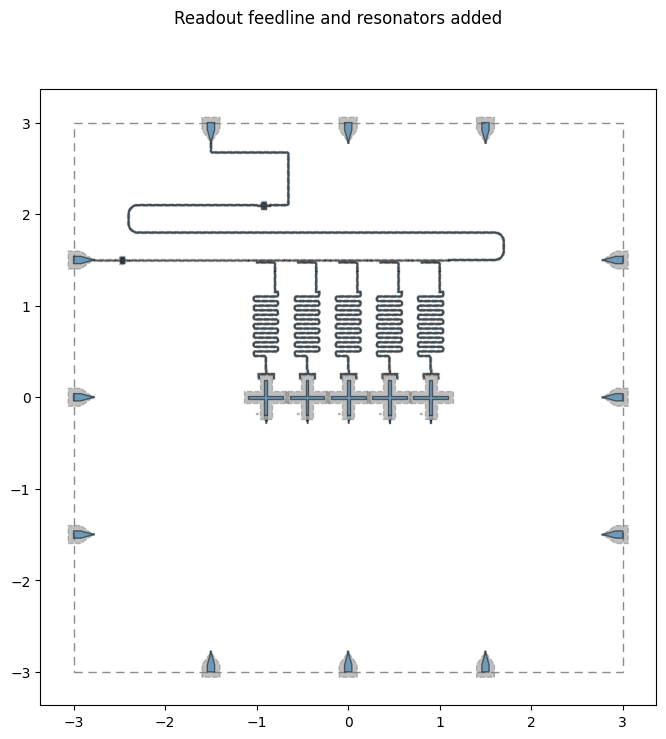

In [8]:
fig = qm.view(design)
fig.suptitle('Readout feedline and resonators added')
fig

### 5. XY and Z control-line routing

Every qubit's XY (drive) and Z (flux) line is routed to its own edge launchpad with `RouteFramed`, using a short list of Manhattan jogs (`start_jogged_extension`) to dodge the qubits and feedline already on the chip.

In [9]:
control_routes = [
    ('XY_pad_0', 'open', 'LP_W2', 'tie', 'XY_Line_0', Dict({})),
    ('Q0', 'flux_line', 'LP_W1', 'tie', 'Z_Line_0', Dict({})),
    ('XY_pad_1', 'open', 'LP_S1', 'tie', 'XY_Line_1', Dict({
        0: ['R', '50um'], 1: ['L', '2000um'], 2: ['R', '200um']})),
    ('Q1', 'flux_line', 'LP_S2', 'tie', 'Z_Line_1', Dict({
        0: ['L', '100um'], 1: ['R', '2000um'], 2: ['L', '200um']})),
    ('XY_pad_2', 'open', 'LP_S3', 'tie', 'XY_Line_2', Dict({
        0: ['R', '50um'], 1: ['L', '1800um'], 2: ['L', '500um']})),
    ('Q2', 'flux_line', 'LP_E1', 'tie', 'Z_Line_2', Dict({
        0: ['L', '100um'], 1: ['R', '1600um'], 2: ['L', '2500um'], 3: ['L', '100um']})),
    ('XY_pad_3', 'open', 'LP_E2', 'tie', 'XY_Line_3', Dict({
        0: ['R', '50um'], 1: ['L', '1400um'], 2: ['L', '2100um'], 3: ['L', '1200um']})),
    ('Q3', 'flux_line', 'LP_E3', 'tie', 'Z_Line_3', Dict({
        0: ['L', '100um'], 1: ['R', '1200um'], 2: ['L', '1700um'], 3: ['L', '800um']})),
    ('XY_pad_4', 'open', 'LP_N3', 'tie', 'XY_Line_4', Dict({
        0: ['R', '50um'], 1: ['L', '1000um'], 2: ['L', '1350um'],
        3: ['L', '3700um'], 4: ['L', '400um']})),
    ('Q4', 'flux_line', 'LP_N2', 'tie', 'Z_Line_4', Dict({
        0: ['L', '100um'], 1: ['R', '800um'], 2: ['L', '950um'],
        3: ['L', '3300um'], 4: ['L', '400um']})),
]

for start_comp, start_pin, end_comp, end_pin, route_name, jogs in control_routes:
    route_options = dict(
        pin_inputs=dict(start_pin=dict(component=start_comp, pin=start_pin),
                         end_pin=dict(component=end_comp, pin=end_pin)),
        lead=dict(start_straight='100um', end_straight='50um', start_jogged_extension=jogs),
        fillet='20um', step_size='0.05mm')
    if 'XY' in route_name:
        route_options['lead']['start_straight'] = '200um'
    RouteFramed(design, route_name, options=route_options)

print('XY and Z control lines routed.')
print(f'Total components: {len(design.components)}')

XY and Z control lines routed.
Total components: 52


### 6. Completed layout

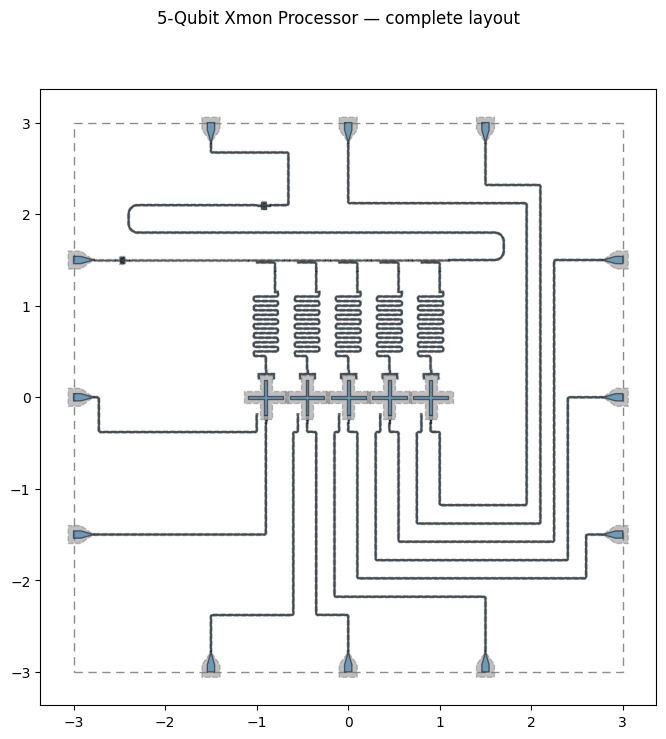

In [10]:
fig = qm.view(design)
fig.suptitle('5-Qubit Xmon Processor — complete layout')
fig

### 7. Export to GDSII

In [11]:
gds_renderer = design.renderers.gds
gds_renderer.options.short_segments_to_not_fillet = 'False'
gds_renderer.export_to_gds('barends_5qubit_processor.gds')
print('Layout exported to GDSII.')

07:55AM 47s WARNING [import_junction_gds_file]: Not able to find file:"../resources/Fake_Junctions.GDS".  Not used to replace junction. Checked directory:"/Users/zlatkominev/CODE_REPOS/quantum_hardware_all/resources".


07:55AM 47s WARNING [_cheese_buffer_maker]: The bounding box for no-cheese is outside of chip size.
Bounding box for chip is (-3.0, -3.0, 3.0, 3.0).
Bounding box with no_cheese buffer is (-3.085, -3.085, 3.085, 3.085).


Layout exported to GDSII.


## References

1. Barends, R. *et al.* Coherent Josephson Qubit Suitable for Scalable Quantum Integrated Circuits. *Phys. Rev. Lett.* **111**, 080502 (2013).
2. Barends, R. *et al.* Superconducting quantum circuits at the surface code threshold for fault tolerance. *Nature* **508**, 500–503 (2014).
3. Sarihan, M. C. Capstone-project solution, [Quantum Device Workshop 2026](https://github.com/quantum-device-consortium/qdw26-workshop-materials).